C:\venv\Investment\investment-311v1\Lib\site-packages\yfinance\scrapers\history.py:239: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.

[*********************100%%**********************]  1 of 1 completed

Final Portfolio Value (Strategy): $9851.26
Profit (Strategy): $-148.74
Number of Successful Trades: 0
Number of Failed Trades: 3
Final Portfolio Value (Buy-and-Hold): $10139.58
Profit (Buy-and-Hold): $139.58


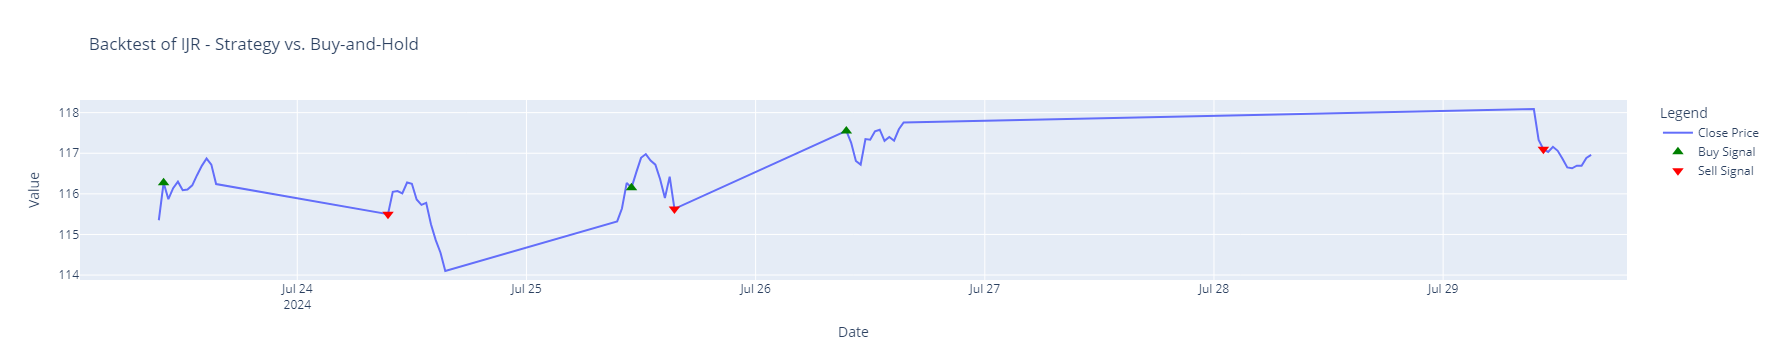

In [71]:
import pandas as pd
import yfinance as yf
import numpy as np
import plotly.graph_objects as go

# Download historical data for IJR for the last 2 months with 30-minute intervals
symbol = 'IJR'
data = yf.download(tickers=symbol, period='5d', interval='30m')

# Calculate MACD and generate buy and sell signals
def calculate_macd(df, fast_period=12, slow_period=26, signal_period=9):
    df['EMA_12'] = df['Close'].ewm(span=fast_period, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=slow_period, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['Signal_Line'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()
    df['Histogram'] = df['MACD'] - df['Signal_Line']
    return df

data = calculate_macd(data)

# Initialize columns
data['Position'] = 0
data['Buy_Signal'] = 0
data['Sell_Signal'] = 0
data['Stop_Loss_Signal'] = 0

# Set stop-loss threshold (e.g., 2%)
stop_loss_threshold = 0.03

# Generate buy, sell, and stop-loss signals
for i in range(1, len(data)):
    if data['MACD'].iloc[i] > data['Signal_Line'].iloc[i] and data['MACD'].iloc[i-1] <= data['Signal_Line'].iloc[i-1] and data['Position'].iloc[i-1] == 0:
        data.at[data.index[i], 'Buy_Signal'] = 1
        data.at[data.index[i], 'Position'] = 1
        buy_price = data['Close'].iloc[i]
    elif data['Position'].iloc[i-1] == 1 and (data['MACD'].iloc[i] < data['Signal_Line'].iloc[i] or data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold)):
        data.at[data.index[i], 'Sell_Signal'] = 1
        if data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold):
            data.at[data.index[i], 'Stop_Loss_Signal'] = 1
        data.at[data.index[i], 'Position'] = 0
    else:
        data.at[data.index[i], 'Position'] = data['Position'].iloc[i-1]

# Calculate strategy returns
data['Strategy_Returns'] = data['Position'].shift() * data['Close'].pct_change()
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()

# Calculate profit
initial_investment = 10000  # Example initial investment amount
data['Portfolio_Value'] = initial_investment * data['Cumulative_Strategy_Returns']

# Buy-and-Hold Strategy
data['Buy_and_Hold_Returns'] = data['Close'] / data['Close'].iloc[0]
data['Buy_and_Hold_Value'] = initial_investment * data['Buy_and_Hold_Returns']

# Extract the final portfolio values to determine profit
final_portfolio_value_strategy = data['Portfolio_Value'].iloc[-1]
final_portfolio_value_bh = data['Buy_and_Hold_Value'].iloc[-1]

profit_strategy = final_portfolio_value_strategy - initial_investment
profit_bh = final_portfolio_value_bh - initial_investment

# Track trades and calculate success and failure
trades = []
current_trade = None

for i in range(len(data)):
    if data['Buy_Signal'].iloc[i] == 1:
        current_trade = {'Buy_Price': data['Close'].iloc[i], 'Buy_Time': data.index[i]}
    elif (data['Sell_Signal'].iloc[i] == 1 or data['Stop_Loss_Signal'].iloc[i] == 1) and current_trade is not None:
        current_trade['Sell_Price'] = data['Close'].iloc[i]
        current_trade['Sell_Time'] = data.index[i]
        current_trade['Profit'] = current_trade['Sell_Price'] - current_trade['Buy_Price']
        trades.append(current_trade)
        current_trade = None

successful_trades = [trade for trade in trades if trade['Profit'] > 0]
failed_trades = [trade for trade in trades if trade['Profit'] <= 0]

num_successful_trades = len(successful_trades)
num_failed_trades = len(failed_trades)

# Display the results
print(f"Final Portfolio Value (Strategy): ${final_portfolio_value_strategy:.2f}")
print(f"Profit (Strategy): ${profit_strategy:.2f}")
print(f"Number of Successful Trades: {num_successful_trades}")
print(f"Number of Failed Trades: {num_failed_trades}")
print(f"Final Portfolio Value (Buy-and-Hold): ${final_portfolio_value_bh:.2f}")
print(f"Profit (Buy-and-Hold): ${profit_bh:.2f}")

# Create Plotly chart
fig = go.Figure()

# Add Close price trace
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Close Price'))

# Add Buy signals
buy_signals = data[data['Buy_Signal'] == 1]
fig.add_trace(go.Scatter(x=buy_signals.index, y=buy_signals['Close'], mode='markers', marker=dict(symbol='triangle-up', size=10, color='green'), name='Buy Signal'))

# Add Sell signals
sell_signals = data[data['Sell_Signal'] == 1]
fig.add_trace(go.Scatter(x=sell_signals.index, y=sell_signals['Close'], mode='markers', marker=dict(symbol='triangle-down', size=10, color='red'), name='Sell Signal'))

# Add Stop Loss signals
stop_loss_signals = data[data['Stop_Loss_Signal'] == 1]
fig.add_trace(go.Scatter(x=stop_loss_signals.index, y=stop_loss_signals['Close'], mode='markers', marker=dict(symbol='x', size=10, color='black'), name='Stop Loss Signal'))

# Update layout
fig.update_layout(title=f"Backtest of IJR - Strategy vs. Buy-and-Hold",
                  xaxis_title="Date",
                  yaxis_title="Value",
                  legend_title="Legend")

# Show chart
fig.show()

# Optionally, save the results to a CSV file
data.to_csv('backtest_results_ijr.csv')


C:\venv\Investment\investment-311v1\Lib\site-packages\yfinance\scrapers\history.py:239: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.

[*********************100%%**********************]  1 of 1 completed

Final Portfolio Value (Strategy): $10538.11
Profit (Strategy): $538.11
Number of Successful Trades: 4
Number of Failed Trades: 2
Final Portfolio Value (Buy-and-Hold): $10499.41
Profit (Buy-and-Hold): $499.41


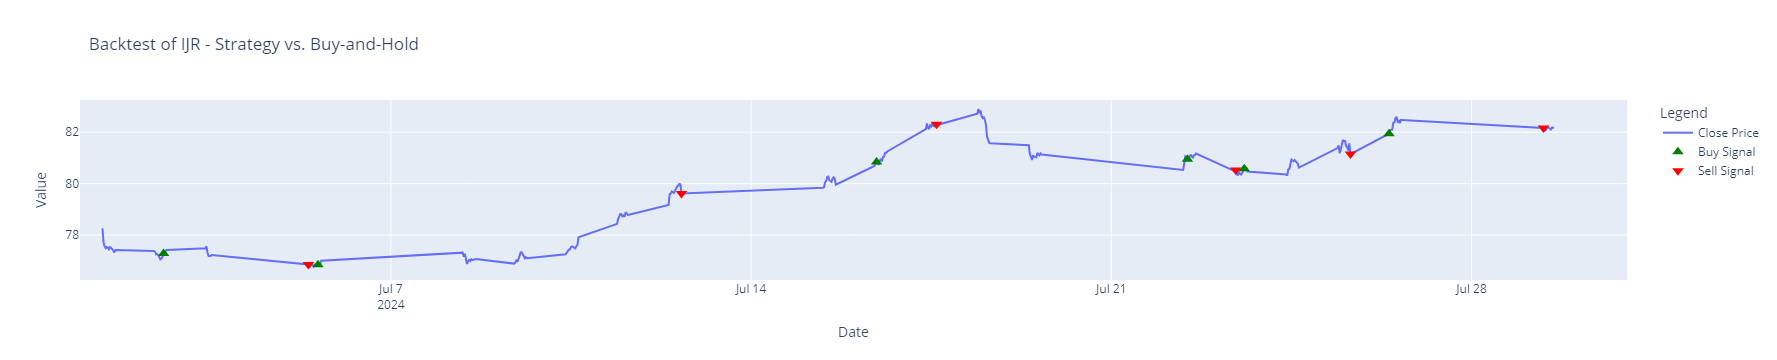

In [65]:
import pandas as pd
import yfinance as yf
import numpy as np
import plotly.graph_objects as go

# Download historical data for IJR for the last 2 months with 30-minute intervals
symbol = 'SCHD'
data = yf.download(tickers=symbol, period='1mo', interval='30m')

# Calculate MACD and generate buy and sell signals
def calculate_macd(df, fast_period=12, slow_period=26, signal_period=9):
    df['EMA_12'] = df['Close'].ewm(span=fast_period, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=slow_period, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['Signal_Line'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()
    df['Histogram'] = df['MACD'] - df['Signal_Line']
    return df

data = calculate_macd(data)

# Initialize columns
data['Position'] = 0
data['Buy_Signal'] = 0
data['Sell_Signal'] = 0
data['Stop_Loss_Signal'] = 0

# Set stop-loss threshold (e.g., 2%)
stop_loss_threshold = 0.01

# Generate buy, sell, and stop-loss signals
for i in range(1, len(data)):
    if data['MACD'].iloc[i] > data['Signal_Line'].iloc[i] and data['MACD'].iloc[i-1] <= data['Signal_Line'].iloc[i-1] and data['Position'].iloc[i-1] == 0:
        data.at[data.index[i], 'Buy_Signal'] = 1
        data.at[data.index[i], 'Position'] = 1
        buy_price = data['Close'].iloc[i]
    elif data['Position'].iloc[i-1] == 1 and (data['MACD'].iloc[i] < data['Signal_Line'].iloc[i] or data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold)):
        data.at[data.index[i], 'Sell_Signal'] = 1
        if data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold):
            data.at[data.index[i], 'Stop_Loss_Signal'] = 1
        data.at[data.index[i], 'Position'] = 0
    else:
        data.at[data.index[i], 'Position'] = data['Position'].iloc[i-1]

# Calculate strategy returns
data['Strategy_Returns'] = data['Position'].shift() * data['Close'].pct_change()
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()

# Calculate profit
initial_investment = 10000  # Example initial investment amount
data['Portfolio_Value'] = initial_investment * data['Cumulative_Strategy_Returns']

# Buy-and-Hold Strategy
data['Buy_and_Hold_Returns'] = data['Close'] / data['Close'].iloc[0]
data['Buy_and_Hold_Value'] = initial_investment * data['Buy_and_Hold_Returns']

# Extract the final portfolio values to determine profit
final_portfolio_value_strategy = data['Portfolio_Value'].iloc[-1]
final_portfolio_value_bh = data['Buy_and_Hold_Value'].iloc[-1]

profit_strategy = final_portfolio_value_strategy - initial_investment
profit_bh = final_portfolio_value_bh - initial_investment

# Track trades and calculate success and failure
trades = []
current_trade = None

for i in range(len(data)):
    if data['Buy_Signal'].iloc[i] == 1:
        current_trade = {'Buy_Price': data['Close'].iloc[i], 'Buy_Time': data.index[i]}
    elif (data['Sell_Signal'].iloc[i] == 1 or data['Stop_Loss_Signal'].iloc[i] == 1) and current_trade is not None:
        current_trade['Sell_Price'] = data['Close'].iloc[i]
        current_trade['Sell_Time'] = data.index[i]
        current_trade['Profit'] = current_trade['Sell_Price'] - current_trade['Buy_Price']
        trades.append(current_trade)
        current_trade = None

successful_trades = [trade for trade in trades if trade['Profit'] > 0]
failed_trades = [trade for trade in trades if trade['Profit'] <= 0]

num_successful_trades = len(successful_trades)
num_failed_trades = len(failed_trades)

# Display the results
print(f"Final Portfolio Value (Strategy): ${final_portfolio_value_strategy:.2f}")
print(f"Profit (Strategy): ${profit_strategy:.2f}")
print(f"Number of Successful Trades: {num_successful_trades}")
print(f"Number of Failed Trades: {num_failed_trades}")
print(f"Final Portfolio Value (Buy-and-Hold): ${final_portfolio_value_bh:.2f}")
print(f"Profit (Buy-and-Hold): ${profit_bh:.2f}")

# Create Plotly chart
fig = go.Figure()

# Add Close price trace
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Close Price'))

# Add Buy signals
buy_signals = data[data['Buy_Signal'] == 1]
fig.add_trace(go.Scatter(x=buy_signals.index, y=buy_signals['Close'], mode='markers', marker=dict(symbol='triangle-up', size=10, color='green'), name='Buy Signal'))

# Add Sell signals
sell_signals = data[data['Sell_Signal'] == 1]
fig.add_trace(go.Scatter(x=sell_signals.index, y=sell_signals['Close'], mode='markers', marker=dict(symbol='triangle-down', size=10, color='red'), name='Sell Signal'))

# Add Stop Loss signals
stop_loss_signals = data[data['Stop_Loss_Signal'] == 1]
fig.add_trace(go.Scatter(x=stop_loss_signals.index, y=stop_loss_signals['Close'], mode='markers', marker=dict(symbol='x', size=10, color='black'), name='Stop Loss Signal'))

# Update layout
fig.update_layout(title=f"Backtest of IJR - Strategy vs. Buy-and-Hold",
                  xaxis_title="Date",
                  yaxis_title="Value",
                  legend_title="Legend")

# Show chart
fig.show()

# Optionally, save the results to a CSV file
data.to_csv('backtest_results_ijr.csv')


C:\venv\Investment\investment-311v1\Lib\site-packages\yfinance\scrapers\history.py:239: FutureWarning:

'T' is deprecated and will be removed in a future version, please use 'min' instead.

[*********************100%%**********************]  1 of 1 completed

Final Portfolio Value (Strategy): $10235.26
Profit (Strategy): $235.26
Number of Successful Trades: 4
Number of Failed Trades: 2
Final Portfolio Value (Buy-and-Hold): $9995.51
Profit (Buy-and-Hold): $-4.49


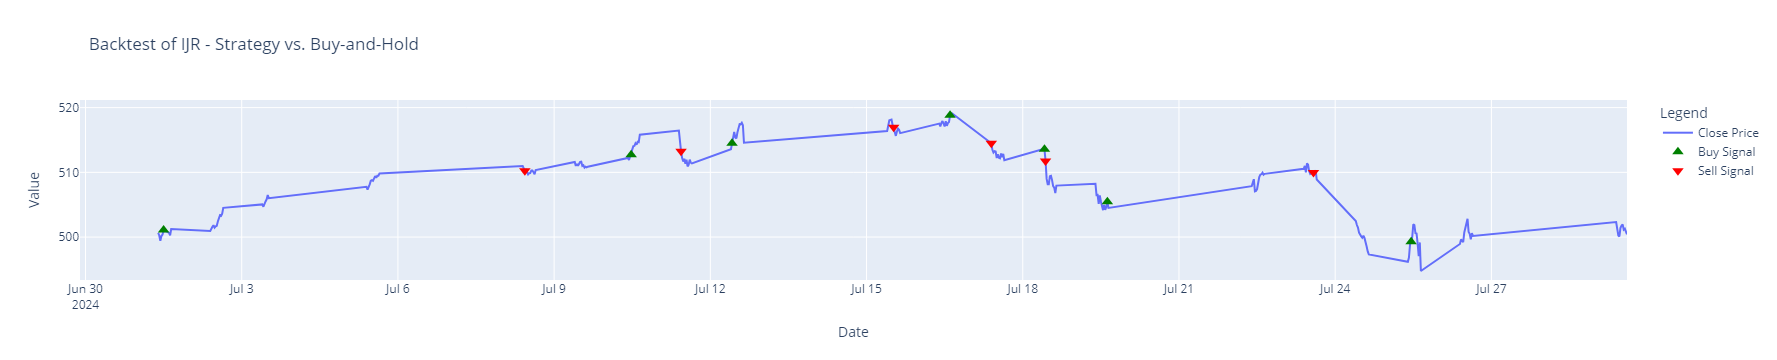

In [66]:
import pandas as pd
import yfinance as yf
import numpy as np
import plotly.graph_objects as go

# Download historical data for IJR for the last 2 months with 30-minute intervals
symbol = 'VOO'
data = yf.download(tickers=symbol, period='1mo', interval='30m')

# Calculate MACD and generate buy and sell signals
def calculate_macd(df, fast_period=12, slow_period=26, signal_period=9):
    df['EMA_12'] = df['Close'].ewm(span=fast_period, adjust=False).mean()
    df['EMA_26'] = df['Close'].ewm(span=slow_period, adjust=False).mean()
    df['MACD'] = df['EMA_12'] - df['EMA_26']
    df['Signal_Line'] = df['MACD'].ewm(span=signal_period, adjust=False).mean()
    df['Histogram'] = df['MACD'] - df['Signal_Line']
    return df

data = calculate_macd(data)

# Initialize columns
data['Position'] = 0
data['Buy_Signal'] = 0
data['Sell_Signal'] = 0
data['Stop_Loss_Signal'] = 0

# Set stop-loss threshold (e.g., 2%)
stop_loss_threshold = 0.02

# Generate buy, sell, and stop-loss signals
for i in range(1, len(data)):
    if data['MACD'].iloc[i] > data['Signal_Line'].iloc[i] and data['MACD'].iloc[i-1] <= data['Signal_Line'].iloc[i-1] and data['Position'].iloc[i-1] == 0:
        data.at[data.index[i], 'Buy_Signal'] = 1
        data.at[data.index[i], 'Position'] = 1
        buy_price = data['Close'].iloc[i]
    elif data['Position'].iloc[i-1] == 1 and (data['MACD'].iloc[i] < data['Signal_Line'].iloc[i] or data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold)):
        data.at[data.index[i], 'Sell_Signal'] = 1
        if data['Close'].iloc[i] <= buy_price * (1 - stop_loss_threshold):
            data.at[data.index[i], 'Stop_Loss_Signal'] = 1
        data.at[data.index[i], 'Position'] = 0
    else:
        data.at[data.index[i], 'Position'] = data['Position'].iloc[i-1]

# Calculate strategy returns
data['Strategy_Returns'] = data['Position'].shift() * data['Close'].pct_change()
data['Cumulative_Strategy_Returns'] = (1 + data['Strategy_Returns']).cumprod()

# Calculate profit
initial_investment = 10000  # Example initial investment amount
data['Portfolio_Value'] = initial_investment * data['Cumulative_Strategy_Returns']

# Buy-and-Hold Strategy
data['Buy_and_Hold_Returns'] = data['Close'] / data['Close'].iloc[0]
data['Buy_and_Hold_Value'] = initial_investment * data['Buy_and_Hold_Returns']

# Extract the final portfolio values to determine profit
final_portfolio_value_strategy = data['Portfolio_Value'].iloc[-1]
final_portfolio_value_bh = data['Buy_and_Hold_Value'].iloc[-1]

profit_strategy = final_portfolio_value_strategy - initial_investment
profit_bh = final_portfolio_value_bh - initial_investment

# Track trades and calculate success and failure
trades = []
current_trade = None

for i in range(len(data)):
    if data['Buy_Signal'].iloc[i] == 1:
        current_trade = {'Buy_Price': data['Close'].iloc[i], 'Buy_Time': data.index[i]}
    elif (data['Sell_Signal'].iloc[i] == 1 or data['Stop_Loss_Signal'].iloc[i] == 1) and current_trade is not None:
        current_trade['Sell_Price'] = data['Close'].iloc[i]
        current_trade['Sell_Time'] = data.index[i]
        current_trade['Profit'] = current_trade['Sell_Price'] - current_trade['Buy_Price']
        trades.append(current_trade)
        current_trade = None

successful_trades = [trade for trade in trades if trade['Profit'] > 0]
failed_trades = [trade for trade in trades if trade['Profit'] <= 0]

num_successful_trades = len(successful_trades)
num_failed_trades = len(failed_trades)

# Display the results
print(f"Final Portfolio Value (Strategy): ${final_portfolio_value_strategy:.2f}")
print(f"Profit (Strategy): ${profit_strategy:.2f}")
print(f"Number of Successful Trades: {num_successful_trades}")
print(f"Number of Failed Trades: {num_failed_trades}")
print(f"Final Portfolio Value (Buy-and-Hold): ${final_portfolio_value_bh:.2f}")
print(f"Profit (Buy-and-Hold): ${profit_bh:.2f}")

# Create Plotly chart
fig = go.Figure()

# Add Close price trace
fig.add_trace(go.Scatter(x=data.index, y=data['Close'], mode='lines', name='Close Price'))

# Add Buy signals
buy_signals = data[data['Buy_Signal'] == 1]
fig.add_trace(go.Scatter(x=buy_signals.index, y=buy_signals['Close'], mode='markers', marker=dict(symbol='triangle-up', size=10, color='green'), name='Buy Signal'))

# Add Sell signals
sell_signals = data[data['Sell_Signal'] == 1]
fig.add_trace(go.Scatter(x=sell_signals.index, y=sell_signals['Close'], mode='markers', marker=dict(symbol='triangle-down', size=10, color='red'), name='Sell Signal'))

# Add Stop Loss signals
stop_loss_signals = data[data['Stop_Loss_Signal'] == 1]
fig.add_trace(go.Scatter(x=stop_loss_signals.index, y=stop_loss_signals['Close'], mode='markers', marker=dict(symbol='x', size=10, color='black'), name='Stop Loss Signal'))

# Update layout
fig.update_layout(title=f"Backtest of IJR - Strategy vs. Buy-and-Hold",
                  xaxis_title="Date",
                  yaxis_title="Value",
                  legend_title="Legend")

# Show chart
fig.show()

# Optionally, save the results to a CSV file
data.to_csv('backtest_results_ijr.csv')
